In [10]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

# Load acoustic envelope predictors
Loads already preprocessed attended and unattended acoustic envelopes.

In [11]:
def compute_subject_envelopes(subject, padded=False):
    """
    Compute and save concatenated envelope predictors for a single subject
    from the .mat file (wavA=attended, wavB=ignored).

    Args:
        subject: Subject ID.
        padded:  Whether to pad each trial before concatenating.
    """
    dst_dir = FUGLSANG_PRED_CONCAT_MAT_DIR / subject
    dst_dir.mkdir(exist_ok=True, parents=True)

    att_name = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, padded)
    ign_name = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.IGNORED,  padded)

    att_path = dst_dir / f"{att_name}_concat.pickle"
    ign_path = dst_dir / f"{ign_name}_concat.pickle"

    if att_path.exists() and ign_path.exists():
        print(f"{subject}: files exist, skipping.")
        return

    print(f"{subject}: computing envelopes...")

    subject_data_file = helper_functions.get_subject_data_file(subject)
    mat = scipy.io.loadmat(subject_data_file, squeeze_me=True, struct_as_record=False)
    data = mat['data']

    att_trials = []
    ign_trials = []

    for att_envelope, ign_envelope in zip(data.wavA, data.wavB):
        time_axis = eelbrain.UTS(0, 1 / data.fsample.wavA, len(att_envelope))

        att_ndvar = eelbrain.NDVar(att_envelope, dims=(time_axis,), name='attended')
        ign_ndvar = eelbrain.NDVar(ign_envelope, dims=(time_axis,), name='ignored')

        if padded:
            att_ndvar = eelbrain.pad(att_ndvar, tstart=-PADDING_ONSET, tstop=att_ndvar.time.tstop + PADDING_OFFSET)
            ign_ndvar = eelbrain.pad(ign_ndvar, tstart=-PADDING_ONSET, tstop=ign_ndvar.time.tstop + PADDING_OFFSET)

        att_trials.append(att_ndvar)
        ign_trials.append(ign_ndvar)

    att_concat = eelbrain.concatenate(att_trials, name=att_name)
    ign_concat = eelbrain.concatenate(ign_trials, name=ign_name)

    eelbrain.save.pickle(att_concat, att_path)
    eelbrain.save.pickle(ign_concat, ign_path)

    print(f"  ✓ Saved {att_path}")
    print(f"  ✓ Saved {ign_path}")

In [12]:
SUBJECTS = helper_functions.fuglsang_get_subjects()

for subject in SUBJECTS:
    compute_subject_envelopes(subject, padded=False)
    compute_subject_envelopes(subject, padded=True)

print("Done computing envelopes.")

S1: files exist, skipping.
S1: files exist, skipping.
S2: files exist, skipping.
S2: files exist, skipping.
S3: files exist, skipping.
S3: files exist, skipping.
S4: files exist, skipping.
S4: files exist, skipping.
S5: files exist, skipping.
S5: files exist, skipping.
S6: files exist, skipping.
S6: files exist, skipping.
S7: files exist, skipping.
S7: files exist, skipping.
S8: files exist, skipping.
S8: files exist, skipping.
S9: files exist, skipping.
S9: files exist, skipping.
S10: files exist, skipping.
S10: files exist, skipping.
S11: files exist, skipping.
S11: files exist, skipping.
S12: files exist, skipping.
S12: files exist, skipping.
S13: files exist, skipping.
S13: files exist, skipping.
S14: files exist, skipping.
S14: files exist, skipping.
S15: files exist, skipping.
S15: files exist, skipping.
S16: files exist, skipping.
S16: files exist, skipping.
S17: files exist, skipping.
S17: files exist, skipping.
S18: files exist, skipping.
S18: files exist, skipping.
Done compu

In [13]:
# SANITY CHECK: Check dimensions of computed envelopes
subject = SUBJECTS[0]
for padded in [False, True]:
    for attention in ATTENTION_TYPE:
        name = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE, attention, padded)
        path = FUGLSANG_PRED_CONCAT_MAT_DIR / subject / f"{name}_concat.pickle"
        if path.exists():
            print(f"  ✓ {name}: {eelbrain.load.unpickle(path)}")
        else:
            print(f"  ✗ {name}: MISSING")

  ✓ attended_envelope: <NDVar 'attended_envelope': 192000 time>
  ✓ ignored_envelope: <NDVar 'ignored_envelope': 192000 time>
  ✗ _envelope: MISSING
  ✓ attended_envelope_padded: <NDVar 'attended_envelope_padded': 196260 time>
  ✓ ignored_envelope_padded: <NDVar 'ignored_envelope_padded': 196260 time>
  ✗ _envelope_padded: MISSING


In [14]:
def save_mat_trial_predictors(subject, padded=False):
    """
    Extract and save per-trial envelope predictors from the .mat file
    into FUGLSANG_PRED_MAT_DIR, matching the naming convention used by
    load_trial_predictors for the self-computed pipeline.

    One pickle per story key (attended + ignored), named:
        <story_key>~envelope.pickle

    Parameters
    ----------
    subject : str
        Subject ID, e.g. 'S1'.
    padded : bool
        Whether to apply trial padding before saving.
    """
    dst_dir = FUGLSANG_PRED_MAT_DIR
    dst_dir.mkdir(exist_ok=True, parents=True)

    suffix = "_padded" if padded else ""
    p_name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE, padded)

    subject_data_file = helper_functions.get_subject_data_file(subject)
    mat  = scipy.io.loadmat(subject_data_file, squeeze_me=True, struct_as_record=False)
    data = mat['data']

    trials = helper_functions.get_trials(subject)

    for trial_idx, (att_wav, ign_wav) in enumerate(zip(data.wavA, data.wavB)):
        trial      = trials[trial_idx]
        att_story  = trial['attended']
        ign_story  = trial['ignored']

        att_path = dst_dir / f'{att_story}~{p_name}.pickle'
        ign_path = dst_dir / f'{ign_story}~{p_name}.pickle'

        time_axis = eelbrain.UTS(0, 1 / data.fsample.wavA, len(att_wav))

        for wav, path, name in [
            (att_wav, att_path, att_story),
            (ign_wav, ign_path, ign_story),
        ]:
            if path.exists():
                print(f"  {name}~{p_name}: exists, skipping.")
                continue

            ndvar = eelbrain.NDVar(wav, dims=(time_axis,), name=name)

            if padded:
                ndvar = eelbrain.pad(
                    ndvar,
                    tstart=-PADDING_ONSET,
                    tstop=ndvar.time.tstop + PADDING_OFFSET,
                )

            eelbrain.save.pickle(ndvar, path)
            print(f"  ✓ {path.name}")

    print(f"{subject}: done.")

In [15]:
for subject in SUBJECTS:
    save_mat_trial_predictors(subject)

S1: loaded 60 trials
  marianne_story3_trial_1~envelope: exists, skipping.
  aske_story4_trial_1~envelope: exists, skipping.
  marianne_story3_trial_2~envelope: exists, skipping.
  aske_story4_trial_2~envelope: exists, skipping.
  marianne_story3_trial_3~envelope: exists, skipping.
  aske_story4_trial_3~envelope: exists, skipping.
  marianne_story3_trial_4~envelope: exists, skipping.
  aske_story4_trial_4~envelope: exists, skipping.
  marianne_story3_trial_5~envelope: exists, skipping.
  aske_story4_trial_5~envelope: exists, skipping.
  marianne_story3_trial_6~envelope: exists, skipping.
  aske_story4_trial_6~envelope: exists, skipping.
  marianne_story3_trial_7~envelope: exists, skipping.
  aske_story4_trial_7~envelope: exists, skipping.
  marianne_story3_trial_8~envelope: exists, skipping.
  aske_story4_trial_8~envelope: exists, skipping.
  marianne_story3_trial_9~envelope: exists, skipping.
  aske_story4_trial_9~envelope: exists, skipping.
  marianne_story3_trial_10~envelope: exists

# Load acoustic onset predictor
Computes the acoustic onset using Eelbrains `edge_detector` function on the acoustic envelope.

In [16]:
def compute_subject_envelope_onsets(subject, padded=False):
    """
    Compute and save concatenated envelope onset predictors for a single subject.
    Loads envelopes from MAT_FILE_CONCAT_DIR, computes onsets via edge detector,
    and saves to MAT_FILE_CONCAT_DIR.

    Args:
        subject: Subject ID.
        padded:  Whether to pad each trial before concatenating.
    """
    dst_dir = FUGLSANG_PRED_CONCAT_MAT_DIR / subject
    dst_dir.mkdir(exist_ok=True, parents=True)

    att_name = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, padded)
    ign_name = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  padded)

    att_path = dst_dir / f"{att_name}_concat.pickle"
    ign_path = dst_dir / f"{ign_name}_concat.pickle"

    if att_path.exists() and ign_path.exists():
        print(f"{subject}: onset files exist, skipping.")
        return

    # --- Load envelopes ---
    env_att_name = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, padded)
    env_ign_name = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.IGNORED,  padded)

    env_att_path = dst_dir / f"{env_att_name}_concat.pickle"
    env_ign_path = dst_dir / f"{env_ign_name}_concat.pickle"

    if not env_att_path.exists() or not env_ign_path.exists():
        print(f"{subject}: envelope files missing, skipping.")
        return

    print(f"{subject}: computing envelope onsets...")

    att_envelope = eelbrain.load.unpickle(env_att_path)
    ign_envelope = eelbrain.load.unpickle(env_ign_path)

    fdim = eelbrain.Scalar('frequency', [0])

    def compute_onset(ndvar, name):
        # 1. Resample to 1000 Hz
        ndvar_1000 = eelbrain.resample(ndvar, 1000)
        # 2. Add frequency dimension
        ndvar_2d = eelbrain.NDVar(ndvar_1000.x[None, :], dims=(fdim, ndvar_1000.time), name=name)
        # 3. Edge detector
        onset = eelbrain.edge_detector(ndvar_2d, c=30, name=name)
        # 4. Resample back to EEG_SAMPLING_RATE
        onset = eelbrain.resample(onset, EEG_SAMPLING_RATE)
        # 5. Remove frequency dimension
        return onset.mean('frequency')

    att_onset = compute_onset(att_envelope, att_name)
    ign_onset = compute_onset(ign_envelope, ign_name)

    eelbrain.save.pickle(att_onset, att_path)
    eelbrain.save.pickle(ign_onset, ign_path)

    print(f"  ✓ Saved {att_path}")
    print(f"  ✓ Saved {ign_path}")

In [17]:
for subject in SUBJECTS:
    compute_subject_envelope_onsets(subject, padded=False)
    compute_subject_envelope_onsets(subject, padded=True)

print("Done computing envelope onsets.")

S1: onset files exist, skipping.
S1: onset files exist, skipping.
S2: onset files exist, skipping.
S2: onset files exist, skipping.
S3: onset files exist, skipping.
S3: onset files exist, skipping.
S4: onset files exist, skipping.
S4: onset files exist, skipping.
S5: onset files exist, skipping.
S5: onset files exist, skipping.
S6: onset files exist, skipping.
S6: onset files exist, skipping.
S7: onset files exist, skipping.
S7: onset files exist, skipping.
S8: onset files exist, skipping.
S8: onset files exist, skipping.
S9: onset files exist, skipping.
S9: onset files exist, skipping.
S10: onset files exist, skipping.
S10: onset files exist, skipping.
S11: onset files exist, skipping.
S11: onset files exist, skipping.
S12: onset files exist, skipping.
S12: onset files exist, skipping.
S13: onset files exist, skipping.
S13: onset files exist, skipping.
S14: onset files exist, skipping.
S14: onset files exist, skipping.
S15: onset files exist, skipping.
S15: onset files exist, skipping

In [18]:
def compute_subject_envelope_onsets_trials(subject, padded=False):
    """
    Compute and save per-trial envelope onset predictors for a single subject
    from the mat-derived per-trial envelope pickles in FUGLSANG_PRED_MAT_DIR.
    """
    FUGLSANG_PRED_MAT_DIR.mkdir(exist_ok=True, parents=True)

    fdim   = eelbrain.Scalar('frequency', [0])
    trials = helper_functions.get_trials(subject)

    env_p_name    = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE,       padded)
    onset_p_name  = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE_ONSET, padded)

    def compute_onset(ndvar, name):
        ndvar_1000 = eelbrain.resample(ndvar, 1000)
        ndvar_2d   = eelbrain.NDVar(ndvar_1000.x[None, :], dims=(fdim, ndvar_1000.time), name=name)
        onset      = eelbrain.edge_detector(ndvar_2d, c=30, name=name)
        onset      = eelbrain.resample(onset, EEG_SAMPLING_RATE)
        return onset.mean('frequency')

    for trial_idx, trial in trials.items():
        for story_key in [trial['attended'], trial['ignored']]:
            env_path   = FUGLSANG_PRED_MAT_DIR / f"{story_key}~{env_p_name}.pickle"
            onset_path = FUGLSANG_PRED_MAT_DIR / f"{story_key}~{onset_p_name}.pickle"

            if onset_path.exists():
                print(f"  {story_key}~{onset_p_name}: exists, skipping.")
                continue

            if not env_path.exists():
                print(f"  {story_key}~{env_p_name}: envelope not found, skipping.")
                continue

            env   = eelbrain.load.unpickle(env_path)
            onset = compute_onset(env, story_key)
            eelbrain.save.pickle(onset, onset_path)
            print(f"  ✓ {onset_path.name}")

    print(f"{subject}: done.")

In [19]:
for subject in SUBJECTS:
    compute_subject_envelope_onsets_trials(subject)

S1: loaded 60 trials
  ✓ marianne_story3_trial_1~envelope_onset.pickle
  ✓ aske_story4_trial_1~envelope_onset.pickle
  ✓ marianne_story3_trial_2~envelope_onset.pickle
  ✓ aske_story4_trial_2~envelope_onset.pickle
  ✓ marianne_story3_trial_3~envelope_onset.pickle
  ✓ aske_story4_trial_3~envelope_onset.pickle
  ✓ marianne_story3_trial_4~envelope_onset.pickle
  ✓ aske_story4_trial_4~envelope_onset.pickle
  ✓ marianne_story3_trial_5~envelope_onset.pickle
  ✓ aske_story4_trial_5~envelope_onset.pickle
  ✓ marianne_story3_trial_6~envelope_onset.pickle
  ✓ aske_story4_trial_6~envelope_onset.pickle
  ✓ marianne_story3_trial_7~envelope_onset.pickle
  ✓ aske_story4_trial_7~envelope_onset.pickle
  ✓ marianne_story3_trial_8~envelope_onset.pickle
  ✓ aske_story4_trial_8~envelope_onset.pickle
  ✓ marianne_story3_trial_9~envelope_onset.pickle
  ✓ aske_story4_trial_9~envelope_onset.pickle
  ✓ marianne_story3_trial_10~envelope_onset.pickle
  ✓ aske_story4_trial_10~envelope_onset.pickle
  ✓ marianne_stor

padded=False: <NDVar 'attended_envelope': 192000 time> <NDVar 'attended_envelope_onset': 192000 time>
padded=True: <NDVar 'attended_envelope_padded': 196260 time> <NDVar 'attended_envelope_onset_padded': 196260 time>


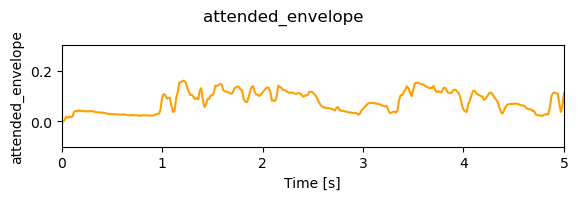

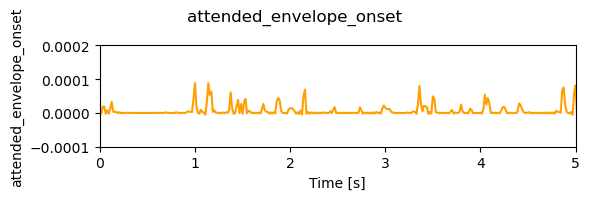

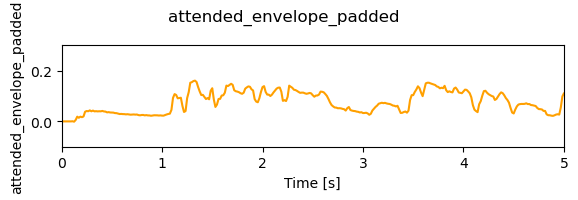

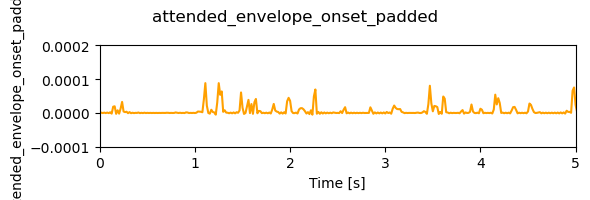

In [20]:
# SANITY CHECK: Plot envelope and onset for one subject
subject = SUBJECTS[0]
dst_dir = FUGLSANG_PRED_CONCAT_MAT_DIR / subject

for padded in [False, True]:
    env_name   = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, padded)
    onset_name = helper_functions.get_attentional_predictor_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, padded)

    envelope = eelbrain.load.unpickle(dst_dir / f"{env_name}_concat.pickle")
    onset    = eelbrain.load.unpickle(dst_dir / f"{onset_name}_concat.pickle")

    print(f"padded={padded}:", envelope, onset)
    eelbrain.plot.UTS([[envelope]], xlim=5, w=6, h=2, title=env_name)
    eelbrain.plot.UTS([[onset]],   xlim=5, w=6, h=2, title=onset_name)